# Imports e Classi di utils

In [20]:
import sys
sys.modules["fhn_notebook"] = sys.modules["__main__"]
__name__ = "fhn_notebook"

from __future__ import annotations

import argparse
import time
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix, eye
from scipy.sparse import diags
from scipy.sparse.linalg import factorized


Array = np.ndarray


In [21]:
@dataclass(frozen=True)
class Config:

    # Parametri dell'equazione e della discretizzazione
    gamma: float = 0.015
    length: float = 1.0
    final_time: float = 4.0
    n_space: int = 128
    dt: float = 1.0e-3
    snapshot_dt: float = 1.0e-2

    # Dimensione base POD per ogni variabile lifted
    ranks: tuple[int, int, int] = (3, 3, 4)  #ranks[0] = w1=s1; ranks[1] = w2=s2; ranks[2] = w3=s1^2; r = 10

    # Paramteri di training/validazione/test
    training_alphas: tuple[float, ...] = (500.0, 5_000.0, 50_000.0)
    training_betas: tuple[float, ...] = (10.0, 12.5, 15.0)

    validation_alpha: float = 20_000.0
    validation_beta: float = 13.5

    test_alpha: float = 100_000.0
    test_beta: float = 17.0

    # Candidati per la regolarizzazione di Tikhonov
    ridge_candidates: tuple[float, ...] = (
        1.0e-12,
        1.0e-10,
        1.0e-8,
        1.0e-6,
        1.0e-4,
        1.0e-2,
    )

    # Cartella nella quale vengono salvati tabelle, grafici e modello.
    output_dir: str = "risultati_fhn"


@dataclass
class FOMOperators:
    #Operatori e griglia necessari per la simulazione FOM.

    x: Array
    dx: float
    d2: csc_matrix
    boundary_vector: Array


@dataclass
class LiftData:
    #Dati prodotti dalla fase di lifting e riduzione POD.

    bases: tuple[Array, Array, Array]
    singular_values: tuple[Array, Array, Array]
    reduced_state: Array
    reduced_derivative: Array
    features: Array
    masks: Array
    quadratic_pairs: list[tuple[int, int]]
    feature_names: list[str]


@dataclass
class LearnedModel:
    #Modello ridotto identificato e statistiche della sua selezione.

    coefficients: Array
    bases: tuple[Array, Array, Array]
    quadratic_pairs: list[tuple[int, int]]
    ranks: tuple[int, int, int]
    regularization: float
    training_residual: float
    validation_error: float


# Soluzione FOM e creazione matrici Snapshots

Risolve l'equazione con FOM e salva pochi in matrici separate per avere gli snapshots

In [22]:
def u0(t: float | Array, alpha: float, beta: float) -> float | Array:
    # Calcola l'ingresso parametrico.
    # g(t; alpha,beta) = alpha * t^3 * exp(-beta*t)

    t_array = np.asarray(t)
    values = alpha * t_array**3 * np.exp(-beta * t_array)

    return float(values) if values.ndim == 0 else values  # Per un ingresso scalare si restituisce un float Python.


def build_boundary_neumann(n: int, length: float = 1.0) -> FOMOperators:
    if n < 3:
        raise ValueError("Servono almeno 3 nodi spaziali.")

    # Griglia uniforme, inclusi i due estremi del dominio.
    x = np.linspace(0.0, length, n)
    dx = x[1] - x[0]

    # u_xx(x_i) ~= (u_{i-1} - 2*u_i + u_{i+1}) / dx^2.
    main = -2.0 * np.ones(n) / dx**2
    off = np.ones(n - 1) / dx**2
    d2 = diags((off, main, off), offsets=(-1, 0, 1), format="lil")

    # Correzioni dei bordi per la formula con punti fantasma.
    d2[0, 1] = 2.0 / dx**2
    d2[-1, -2] = 2.0 / dx**2
    d2 = d2.tocsc()

    # u_xx = D2*u + boundary_vector*g(t).
    boundary_vector = np.zeros(n)
    boundary_vector[0] = -2.0 / dx

    return FOMOperators(
        x=x,
        dx=dx,
        d2=d2,
        boundary_vector=boundary_vector,
    )


def fhn_semidiscrete_rhs(
    s1: Array,
    s2: Array,
    g_value: float | Array,
    operators: FOMOperators,
    gamma: float,
) -> tuple[Array, Array]:

    # Parte del Laplaciano indipendente dall'ingresso.
    laplacian = operators.d2 @ s1
    g_array = np.asarray(g_value)

    # La funzione accetta un singolo stato o una matrice di snapshot
    if s1.ndim == 1:
        laplacian = laplacian + operators.boundary_vector * float(g_array)
    else:
        laplacian = laplacian + operators.boundary_vector[:, None] * g_array.reshape(1, -1)

    # Termine di reazione non lineare della prima equazione.
    R = -s1**3 + 1.1 * s1**2 - 0.1 * s1 + s2 + 0.05

    # Dalla prima PDE:  gamma*s1_t = gamma^2*s1_xx + R  ===>  s1_t = gamma*s1_xx + R/gamma.
    ds1 = gamma * laplacian + R / gamma

    # Seconda equazione locale, priva di derivate spaziali.
    ds2 = 0.5 * s1 - 2.0 * s2 + 0.05
    return ds1, ds2


def simulate_fhn_fom(
    alpha: float,
    beta: float,
    config: Config,
    operators: FOMOperators,
) -> tuple[Array, Array, Array, float]:

    #ogni quanti passi della simulazione salvare uno snapshot
    ratio = config.snapshot_dt / config.dt   
    save_stride = int(round(ratio))
    if not np.isclose(ratio, save_stride):
        raise ValueError("snapshot_dt deve essere multiplo intero di dt.")

    #tempo finale / passo temporale = numero di passi della simulazione
    n_steps_float = config.final_time / config.dt   
    n_steps = int(round(n_steps_float))
    if not np.isclose(n_steps_float, n_steps):
        raise ValueError("final_time deve essere multiplo intero di dt.")

    # Numero di colonne delle matrici di snapshot, incluso t=0.
    n_snapshots = n_steps // save_stride + 1
    snapshot_times = np.arange(n_snapshots) * config.snapshot_dt

    # Condizioni iniziali nulle.
    s1 = np.zeros(config.n_space)
    s2 = np.zeros(config.n_space)
    s1_snapshots = np.empty((config.n_space, n_snapshots))
    s2_snapshots = np.empty((config.n_space, n_snapshots))

    # Salvataggio dello stato iniziale nelle prime colonne delle matrici di snapshot.
    s1_snapshots[:, 0] = s1  
    s2_snapshots[:, 0] = s2

    # Poiché la matrice non cambia nel tempo, la fattorizzazione viene calcolata una sola volta prima del ciclo temporale.
    implicit_matrix = eye(config.n_space, format="csc") - config.dt * config.gamma * operators.d2
    solve_diffusion = factorized(implicit_matrix)  #Metodo scipy che fattorizza LU e restituisce una funzione che risolve il sistema lineare dato un termine noto.

    snapshot_index = 1
    start = time.perf_counter()

    # Ciclo temporale del Full Order Model
    for step in range(1, n_steps + 1):
        t_next = step * config.dt

        # Ingresso imposto al bordo al nuovo istante.
        g_next = u0(t_next, alpha, beta)

        # La parte non lineare viene valutata esplicitamente allo stato noto.
        R_old = -s1**3 + 1.1 * s1**2 - 0.1 * s1 + s2 + 0.05

        # Termine noto della prima equazione IMEX.
        rhs_s1 = s1 + config.dt * R_old / config.gamma + config.dt * config.gamma * operators.boundary_vector * g_next

        # Risoluzione del sistema lineare per ottenere s1 al passo successivo.
        s1_new = solve_diffusion(rhs_s1)

        # Trattamento implicito del termine -2*s2.
        s2_new = (s2 + config.dt * (0.5 * s1_new + 0.05)) / (1.0 + 2.0 * config.dt)

        if not np.all(np.isfinite(s1_new)) or not np.all(np.isfinite(s2_new)):
            raise FloatingPointError(
                f"FOM non finito per alpha={alpha:g}, beta={beta:g}."
            )

        s1, s2 = s1_new, s2_new

        # Salvataggio soltanto agli istanti di snapshot, non a ogni passo.
        if step % save_stride == 0:
            s1_snapshots[:, snapshot_index] = s1
            s2_snapshots[:, snapshot_index] = s2
            snapshot_index += 1

    runtime = time.perf_counter() - start
    return snapshot_times, s1_snapshots, s2_snapshots, runtime


# Generazione spazio dei parametri

In [23]:
def training_parameter_pairs(config: Config) -> list[tuple[float, float]]:
    return [(alpha, beta) for alpha in config.training_alphas for beta in config.training_betas]

def generate_training_data(config: Config, operators: FOMOperators, ) -> tuple[Array, Array, Array, Array, list[dict[str, float]]]:

    # Liste temporanee nelle quali vengono memorizzati i blocchi di snapshot.
    s1_blocks: list[Array] = []
    s2_blocks: list[Array] = []
    g_blocks: list[Array] = []
    run_info: list[dict[str, float]] = []
    snapshot_times: Array | None = None

    for index, (alpha, beta) in enumerate(training_parameter_pairs(config), start=1):  #itero fra tutti i parametri di training
        times, s1, s2, runtime = simulate_fhn_fom(alpha, beta, config, operators)
        if snapshot_times is None:
            snapshot_times = times

        # Accumulo dei risultati. 
        s1_blocks.append(s1) # hstack solo alla fine, piu efficiente di fare hstack ad ogni iterazione
        s2_blocks.append(s2)
        g_blocks.append(u0(times, alpha, beta))
        run_info.append(
            {
                "simulazione": index,
                "alpha": alpha,
                "beta": beta,
                "tempo_FOM_s": runtime,
            }
        )
        print(
            f"Training {index:2d}/9: "
            f"alpha={alpha:8.0f}, beta={beta:4.1f}, "
            f"runtime={runtime:7.3f} s"
        )

    assert snapshot_times is not None
    return (
        snapshot_times,
        np.hstack(s1_blocks),
        np.hstack(s2_blocks),
        np.concatenate(g_blocks),
        run_info,
    )

# Funzioni per basi POD

In [24]:
def pod_basis(data: Array, rank: int) -> tuple[Array, Array]:

    # Siccome Stot è (Nx, Nt_snaps * N_config_params) ===> Stot@Stot.T è (Nx, Nx)
    # Noto che per SVD, Stot@Stot.T = U @ Sigma^2 @ U^T, dove U sono i modi POD e Sigma i valori singolari
    # Quindi diagonalizzazoone di Stot@Stot.T fornisce direttamente i modi POD e i valori singolari al quadrato per una matrice + piccola.

    S = data @ data.T

    # C è simmetrica semidefinita positiva: eigh è il solver appropriato.
    eigenvalues, eigenvectors = np.linalg.eigh(S)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = np.maximum(eigenvalues[order], 0.0)  # piccoli autovalori negativi possono comparire per errori di round-off.
    u = eigenvectors[:, order]  #ordino autovettori in maniera decrescente secondo gli autovalori

    # Gli autovalori di S*S^T sono i quadrati dei valori singolari di S.
    singular_values = np.sqrt(eigenvalues)

    if rank > u.shape[1]:
        raise ValueError(
            f"Rank richiesto {rank}, ma sono disponibili {u.shape[1]} modi."
        )
    return u[:, :rank], singular_values


def relative_energy_lost(singular_values: Array) -> Array:

    # Energia relativa scartata dopo aver mantenuto i primi r modi.
    total = np.sum(singular_values**2)
    retained = np.cumsum(singular_values**2)  #somma cumulativa dei valori singolari al quadrato
    return np.maximum(1.0 - retained / total, np.finfo(float).tiny)


def modes_for_retained_energy(singular_values: Array, percentage: float) -> int:

    # Numero minimo di modi necessario per trattenere una data energia.
    target = percentage / 100.0
    cumulative = np.cumsum(singular_values**2)
    cumulative /= cumulative[-1]
    return int(np.searchsorted(cumulative, target) + 1)

# Utils per Operator Inference

In [25]:
def quadratic_features(reduced_state: Array) -> tuple[Array, list[tuple[int, int]]]:
    # reduced_state ha forma (r,K): r coordinate e K snapshot.
    dimension, _ = reduced_state.shape

    # Si considerano soltanto le coppie i<=j evitando di inserire sia x_i*x_j sia x_j*x_i.
    pairs = [ (i, j) for i in range(dimension) for j in range(i, dimension)]
    values = np.vstack([reduced_state[i] * reduced_state[j] for i, j in pairs]) #Genero la matrice Q
    return values, pairs


def quadratic_vector( reduced_state: Array, pairs: Sequence[tuple[int, int]]) -> Array:
    # Versione vettoriale di quadratic_features per un singolo stato ridotto. (Utile per la simulazione del modello ridotto)
    return np.fromiter((reduced_state[i] * reduced_state[j] for i, j in pairs), dtype=float, count=len(pairs))



def block_of_index(index: int, ranks: tuple[int, int, int]) -> int:

    #Restituisce il blocco lifted al quale appartiene una coordinata ridotta.
    #0 -> coordinate di w1=s1
    #1 -> coordinate di w2=s2
    #2 -> coordinate di w3=s1^2

    #es : ranks = (3,3,4) -> coordinate 0,1,2 appartengono a w1; coordinate 3,4,5 appartengono a w2; coordinate 6,7,8,9 appartengono a w3

    r1, r2, _ = ranks
    if index < r1: return 0
    if index < r1 + r2: return 1
    return 2


def feature_matrix( reduced_state: Array, g_values: Array) -> tuple[Array, list[tuple[int, int]], list[str]]:

    # wdot = A w + H q(w) + N w g + B g + C.

    # Blocco quadratico H*q(x).
    quadratic, pairs = quadratic_features(reduced_state)

    # Blocco bilineare N*x*g. Il reshape permette il broadcasting su tutte le coordinate ridotte.
    bilinear = reduced_state * g_values.reshape(1, -1)

    # Termine affine/costante C.
    constant = np.ones((1, reduced_state.shape[1]))

    # Matrice delle feature:
    #
    #     Phi = [ x
    #           q(x)
    #           x*g
    #           g
    #           1   ].
    #
    # Ogni colonna corrisponde a uno snapshot.
    features = np.vstack(
        (
            reduced_state,
            quadratic,
            bilinear,
            g_values.reshape(1, -1),
            constant,
        )
    )

    dimension = reduced_state.shape[0]
    names = [f"x[{i}]" for i in range(dimension)]
    names += [f"x[{i}]*x[{j}]" for i, j in pairs]
    names += [f"x[{i}]*g" for i in range(dimension)]
    names += ["g", "1"]
    return features, pairs, names

# Creazione maschera fisica

Rende True solo le zone della matrice delle features che effettivamente possono essere usate

In [26]:
def build_physics_masks(ranks: tuple[int, int, int], pairs: Sequence[tuple[int, int]]) -> Array:

    #Struttura ammessa:
    #dot(w1):
    #    lineare w1,w2; quadratico w1*w1,w1*w3; input g; costante
    #dot(w2):
    #    lineare w1,w2; costante
    #dot(w3):
    #    lineare w1,w3;
    #    quadratico w1*w1,w1*w2,w1*w3,w3*w3;
    #    bilineare w1*g

    dimension = sum(ranks)
    n_quadratic = len(pairs)
    # [ lineari | quadratiche | bilineari | g | 1 ] segno dove inizia ognuno
    linear_start = 0
    quadratic_start = dimension
    bilinear_start = quadratic_start + n_quadratic
    input_index = bilinear_start + dimension
    constant_index = input_index + 1
    n_features = constant_index + 1

    # masks[k,j]=True significa che la feature j può comparire nell'equazione della coordinata ridotta k.
    masks = np.zeros((dimension, n_features), dtype=bool)

    index_blocks = np.array([block_of_index(i, ranks) for i in range(dimension)])  # es per ranks=(3,3,4) -> [0,0,0,1,1,1,2,2,2,2] 
    pair_blocks = [tuple(sorted((index_blocks[i], index_blocks[j]))) for i, j in pairs] #es per ranks=(3,3,4) -> [(0,0),(0,1),(0,2),(1,1),(1,2),(2,2)]

    # Costruzione riga per riga della struttura ammessa.
    for output in range(dimension):
        output_block = int(index_blocks[output])

        # equazioni del blocco w1=s1
        if output_block == 0:
            masks[output, linear_start:quadratic_start] = np.isin(index_blocks, (0, 1))  #parte lineare: appartengono a w1 o w2
            for q_index, blocks in enumerate(pair_blocks):
                if blocks in {(0, 0), (0, 2)}:    #parte quadratica: coppie w1w1 e w1w3
                    masks[output, quadratic_start + q_index] = True
            masks[output, input_index] = True
            masks[output, constant_index] = True

        # equazioni del blocco w2=s2
        elif output_block == 1:
            masks[output, linear_start:quadratic_start] = np.isin(index_blocks, (0, 1))  #parte lineare: appartengono a w1 o w2
            masks[output, constant_index] = True

        # equazioni del blocco w3=s1^2
        else:
            masks[output, linear_start:quadratic_start] = np.isin(index_blocks, (0, 2))  #parte lineare: appartengono a w1 o w3
            for q_index, blocks in enumerate(pair_blocks):
                if blocks in {(0, 0), (0, 1), (0, 2), (2, 2)}:  #parte quadratica: coppie w1w1, w1w2, w1w3, w3w3
                    masks[output, quadratic_start + q_index] = True
            masks[output,bilinear_start:input_index] = index_blocks == 0  #parte bilineare: solo w1*g

    return masks

# Utils per Lifting

In [27]:
def build_lift_data(s1_snapshots: Array, s2_snapshots: Array, g_values: Array, config: Config, operators: FOMOperators) -> LiftData:
    # 1. Applicazione della mappa di lifting agli snapshot del FOM.
    w1 = s1_snapshots
    w2 = s2_snapshots
    w3 = s1_snapshots**2

    # 2. Calcolo delle basi POD per ogni variabile lifted.
    psi1, sv1 = pod_basis(w1, config.ranks[0])
    psi2, sv2 = pod_basis(w2, config.ranks[1])
    psi3, sv3 = pod_basis(w3, config.ranks[2])

    # 3. Proiezione degli snapshot nelle basi POD.
    x1 = psi1.T @ w1
    x2 = psi2.T @ w2
    x3 = psi3.T @ w3

    #   Stato ridotto lifted completo:
    reduced_state = np.vstack((x1, x2, x3))

    # 4. Derivate secondo il modello FOM e proiezione nelle basi POD.
    #   Prima si ricostruiscono gli stati lifted proiettati: w_proj = Psi * Psi^T * w.
    #   Poi si applica la reverse lifting: T(w1,w2,w3) = (w1,w2).
    #   Ignora w3 perché s1 e s2 sono già contenuti esplicitamente nei primi due blocchi.
    w1_projected = psi1 @ x1
    w2_projected = psi2 @ x2

    # Valutazione del modello FOM sugli stati proiettati.
    ds1, ds2 = fhn_semidiscrete_rhs(
        w1_projected,
        w2_projected,
        g_values,
        operators,
        config.gamma,
    )

    # Regola della catena per w3=s1^2: dw3/dt = 2*s1*ds1/dt.
    dw3 = 2.0 * w1_projected * ds1

    # Proiezione delle derivate nelle tre basi POD.
    reduced_derivative = np.vstack(
        (
            psi1.T @ ds1,
            psi2.T @ ds2,
            psi3.T @ dw3,
        )
    )

    # 5. Matrice delle feature e maschere di struttura ammessa per l'identificazione del modello ridotto.
    features, pairs, feature_names = feature_matrix(
        reduced_state, g_values
    )
    masks = build_physics_masks(config.ranks, pairs)

    return LiftData(
        bases=(psi1, psi2, psi3),
        singular_values=(sv1, sv2, sv3),
        reduced_state=reduced_state,
        reduced_derivative=reduced_derivative,
        features=features,
        masks=masks,
        quadratic_pairs=pairs,
        feature_names=feature_names,
    )

# Trovo la soluzione con Least Squares regolarizzato

In [28]:
def fit_masked_ridge(features: Array, targets: Array, masks: Array, regularization: float) -> tuple[Array, float]:

    D = features.T   #[X.T | Q(X).T | (X \kron g).T | g.T | 1.T] ovvero reduced_features nello spazio POD

    #il problema è min||D @ THETA.T - reduced_derivative.T||  con THETA matrice dei learned operators

    n_outputs, n_features = targets.shape[0], features.shape[0]

    # Ogni riga conterrà i coefficienti di una singola equazione ridotta.
    coefficients = np.zeros((n_outputs, n_features))

    for output in range(n_outputs):   #faccio una colonna di theta alla volta con problemi indipendenti
        active = np.flatnonzero(masks[output])   # Indici delle sole feature permesse dalla maschera fisica.
        if active.size == 0:
            raise ValueError(f"Nessuna feature attiva per l'uscita {output}.")

        active_D = D[:, active]

        # Normalizzazione delle colonne. Senza questa operazione feature troppo grandi/piccole potrebbero rendere il problema mal condizionato.
        column_norms = np.linalg.norm(active_D, axis=0)
        column_norms[column_norms == 0.0] = 1.0
        scaled_D = active_D / column_norms

        #   [ D              ] theta ~= [ y ]
        #   [ sqrt(lambda) I ]          [ 0 ].
        augmented_D = np.vstack((scaled_D, np.sqrt(regularization) * np.eye(active.size)))
        augmented_target = np.concatenate((targets[output], np.zeros(active.size)))

        scaled_solution, *_ = np.linalg.lstsq(augmented_D, augmented_target, rcond=None)
        coefficients[output, active] = (scaled_solution / column_norms)

    # Residuo relativo globale sulle derivate di training.
    residual = (
        np.linalg.norm(coefficients @ features - targets, ord="fro")
        / np.linalg.norm(targets, ord="fro")
    )
    return coefficients, float(residual)

# Utils per ROM e calcolo errori

In [29]:
def rom_feature_vector(state: Array, g_value: float, pairs: Sequence[tuple[int, int]]) -> Array:
    # Versione online: costruisce features durante il training per un singolo stato ridotto
    quadratic = quadratic_vector(state, pairs)
    return np.concatenate(
        (
            state,
            quadratic,
            state * g_value,
            np.array([g_value, 1.0]),
        )
    )


def simulate_lift_rom(
    coefficients: Array,
    bases: tuple[Array, Array, Array],
    pairs: Sequence[tuple[int, int]],
    alpha: float,
    beta: float,
    snapshot_times: Array,
    config: Config,
) -> tuple[Array, Array, Array, float, bool]:
    
    dimension = coefficients.shape[0]  #r1, r2, r3 <==> dimensione stato ridotto è 3

    # Gli stati FOM iniziali sono nulli, quindi anche tutte le coordinate ridotte iniziali sono nulle.
    initial_state = np.zeros(dimension)

    def rhs(t: float, state: Array) -> Array:

        g_value = u0(t, alpha, beta)  # alpha * t^3 * e^{-beta*t}

        # calcolo delle features in versione vettoriale
        features = rom_feature_vector(state, g_value, pairs)

        # uso il modello appreso per calcolare xdot 
        derivative = coefficients @ features
        if not np.all(np.isfinite(derivative)):
            return np.full_like(state, np.nan)
        return derivative

    start = time.perf_counter()


    #sto facendo risolvere xdot = f(t,x(t))
    solution = solve_ivp(
        rhs,  #la funzione che calcola x
        (0.0, config.final_time),
        initial_state,
        t_eval=snapshot_times,
        method="BDF",       # BDF è un integratore implicito adatto a sistemi potenzialmente con scale temporali diverse.
        rtol=1.0e-7,
        atol=1.0e-9,
        max_step=config.snapshot_dt,
    )
    runtime = time.perf_counter() - start

    # Un modello è considerato stabile soltanto se:    
    stable = (
        solution.success   # il solver termina con successo
        and solution.y.shape[1] == snapshot_times.size  # produce tutti gli snapshot richiesti
        and np.all(np.isfinite(solution.y))  # non genera NaN/Inf;
        and np.max(np.abs(solution.y)) < 1.0e8    # non raggiunge ampiezze chiaramente non fisiche.
    )

    if not stable:
        empty = np.full(
            (bases[0].shape[0], snapshot_times.size), np.nan
        )
        return empty, empty.copy(), solution.y, runtime, False

    # Reverse lifting e ricostruzione spaziale.
    r1, r2, _ = config.ranks
    reduced = solution.y

    # Primo blocco: coordinate ridotte di w1=s1.
    s1_reconstructed = bases[0] @ reduced[:r1]

    # Secondo blocco: coordinate ridotte di w2=s2.
    s2_reconstructed = bases[1] @ reduced[r1 : r1 + r2]
    return (
        s1_reconstructed,
        s2_reconstructed,
        reduced,
        runtime,
        True,
    )


def trajectory_relative_error(
    s1_prediction: Array,
    s2_prediction: Array,
    s1_reference: Array,
    s2_reference: Array,
) -> float:

    prediction = np.vstack((s1_prediction, s2_prediction))
    reference = np.vstack((s1_reference, s2_reference))
    return float(
        np.linalg.norm(prediction - reference, ord="fro")
        / np.linalg.norm(reference, ord="fro")
    )


def choose_regularization(
    lift_data: LiftData,
    validation_reference: tuple[Array, Array, Array],
    config: Config,
) -> tuple[LearnedModel, pd.DataFrame]:
    validation_times, validation_s1, validation_s2 = validation_reference
    records: list[dict[str, float | bool]] = []
    best_model: LearnedModel | None = None

    # Si prova ogni valore candidato di lambda.
    for regularization in config.ridge_candidates:
        # Identificazione degli operatori sul medesimo training.
        coefficients, training_residual = fit_masked_ridge(
            lift_data.features,
            lift_data.reduced_derivative,
            lift_data.masks,
            regularization,
        )
        pred_s1, pred_s2, _, _, stable = simulate_lift_rom(
            coefficients,
            lift_data.bases,
            lift_data.quadratic_pairs,
            config.validation_alpha,
            config.validation_beta,
            validation_times,
            config,
        )

        # Un modello instabile riceve errore infinito e viene scartato.
        validation_error = np.inf
        if stable:
            validation_error = trajectory_relative_error(
                pred_s1,
                pred_s2,
                validation_s1,
                validation_s2,
            )

        records.append(
            {
                "lambda": regularization,
                "residuo_derivate_training": training_residual,
                "errore_validazione": validation_error,
                "stabile": stable,
            }
        )
        print(
            f"lambda={regularization:9.1e} | "
            f"residuo training={training_residual:9.3e} | "
            f"errore validazione={validation_error:9.3e} | "
            f"stabile={stable}"
        )

        # Aggiornamento del modello migliore secondo l'errore di validazione.
        if stable and (
            best_model is None
            or validation_error < best_model.validation_error
        ):
            best_model = LearnedModel(
                coefficients=coefficients,
                bases=lift_data.bases,
                quadratic_pairs=lift_data.quadratic_pairs,
                ranks=config.ranks,
                regularization=regularization,
                training_residual=training_residual,
                validation_error=validation_error,
            )

    if best_model is None:
        raise RuntimeError(
            "Nessuna regolarizzazione ha prodotto un ROM stabile. "
            "Provare rank più bassi o lambda più grandi."
        )

    return best_model, pd.DataFrame.from_records(records)


# Tabelle, grafici e salvataggio del modello

In [30]:
def energy_table(
    singular_values: tuple[Array, Array, Array],
) -> pd.DataFrame:
    """
    Costruisce una tabella analoga alla tabella energetica del MATLAB.

    Per ciascuna soglia indica quanti modi servono nei tre blocchi lifted.
    """
    percentages = (99.9, 99.99, 99.999, 99.9999)
    rows = []
    for percentage in percentages:
        modes = [
            modes_for_retained_energy(values, percentage)
            for values in singular_values
        ]
        rows.append(
            {
                "energia_trattenuta_percento": percentage,
                "modi_w1": modes[0],
                "modi_w2": modes[1],
                "modi_w3": modes[2],
                "dimensione_totale": sum(modes),
            }
        )
    return pd.DataFrame(rows)


def save_energy_plot(
    singular_values: tuple[Array, Array, Array],
    output_dir: Path,
) -> None:
    """Salva il decadimento dell'energia relativa persa dei tre blocchi."""
    plt.figure(figsize=(8.0, 5.0))
    labels = ("w1 = s1", "w2 = s2", "w3 = s1^2")
    max_modes = min(20, min(len(values) for values in singular_values))
    mode_indices = np.arange(1, max_modes + 1)

    for values, label in zip(singular_values, labels):
        loss = relative_energy_lost(values)
        plt.semilogy(mode_indices, loss[:max_modes], label=label)

    plt.xlabel("Numero di modi trattenuti")
    plt.ylabel("Energia relativa persa")
    plt.title("Spettro energetico dei dati di training")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "spettro_energia.png", dpi=180)
    plt.close()


def save_time_trace(
    times: Array,
    x: Array,
    fom: Array,
    rom: Array,
    variable_name: str,
    output_dir: Path,
) -> None:
    """Confronta FOM e ROM nel nodo più vicino al centro del dominio."""
    center_index = int(np.argmin(np.abs(x - 0.5)))
    plt.figure(figsize=(8.0, 4.5))
    plt.plot(times, fom[center_index], label="FOM")
    plt.plot(times, rom[center_index], label="Lift & Learn")
    plt.xlabel("Tempo")
    plt.ylabel(f"{variable_name}(x=0.5,t)")
    plt.title(f"Evoluzione temporale di {variable_name} al centro")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / f"traccia_{variable_name}.png", dpi=180)
    plt.close()


def save_final_profile(
    x: Array,
    fom: Array,
    rom: Array,
    variable_name: str,
    output_dir: Path,
) -> None:
    """Confronta i profili spaziali FOM e ROM all'istante finale."""
    plt.figure(figsize=(8.0, 4.5))
    plt.plot(x, fom[:, -1], label="FOM")
    plt.plot(x, rom[:, -1], label="Lift & Learn")
    plt.xlabel("x")
    plt.ylabel(f"{variable_name}(x,T)")
    plt.title(f"Profilo finale di {variable_name}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / f"profilo_finale_{variable_name}.png", dpi=180)
    plt.close()


def save_model(
    model: LearnedModel,
    config: Config,
    output_dir: Path,
) -> None:
    """
    Salva il modello in formato NPZ.

    Il file contiene tutto ciò che serve per ricostruire e simulare il ROM:
    coefficienti, basi POD, coppie quadratiche, rank e regolarizzazione.
    """
    psi1, psi2, psi3 = model.bases
    pair_i = np.array([pair[0] for pair in model.quadratic_pairs])
    pair_j = np.array([pair[1] for pair in model.quadratic_pairs])

    np.savez_compressed(
        output_dir / "modello_liftlearn_fhn.npz",
        coefficients=model.coefficients,
        psi1=psi1,
        psi2=psi2,
        psi3=psi3,
        pair_i=pair_i,
        pair_j=pair_j,
        ranks=np.array(config.ranks),
        regularization=np.array(model.regularization),
        gamma=np.array(config.gamma),
    )


# Esecuzione con $\,(r_1,r_2,r_3)=(2,2,3)$

In [31]:
# Configurazione della presentazione con rank totale r=7.
config = replace(
    Config(),
    ranks=(2, 2, 3),
    output_dir="risultati_fhn_notebook_ranks_223",
)
output_dir = Path(config.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)
operators = build_boundary_neumann(config.n_space, config.length)

print(config)
assert config.ranks == (2, 2, 3)


Config(gamma=0.015, length=1.0, final_time=4.0, n_space=128, dt=0.001, snapshot_dt=0.01, ranks=(2, 2, 3), training_alphas=(500.0, 5000.0, 50000.0), training_betas=(10.0, 12.5, 15.0), validation_alpha=20000.0, validation_beta=13.5, test_alpha=100000.0, test_beta=17.0, ridge_candidates=(1e-12, 1e-10, 1e-08, 1e-06, 0.0001, 0.01), output_dir='risultati_fhn_notebook_ranks_223')


## Soluzione FOM della presentazione

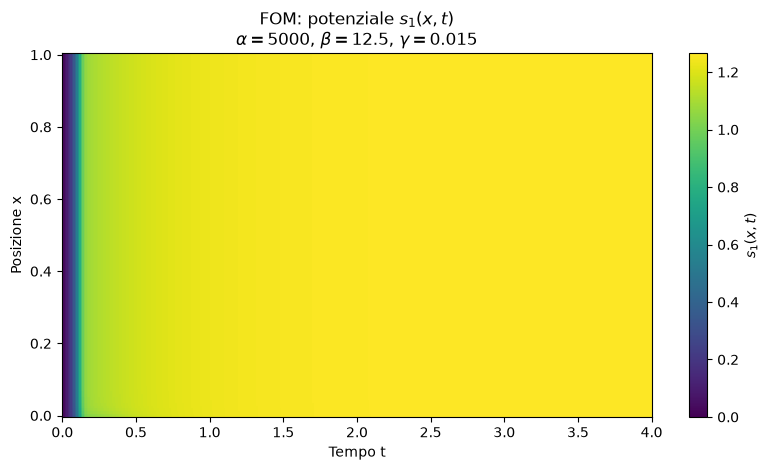

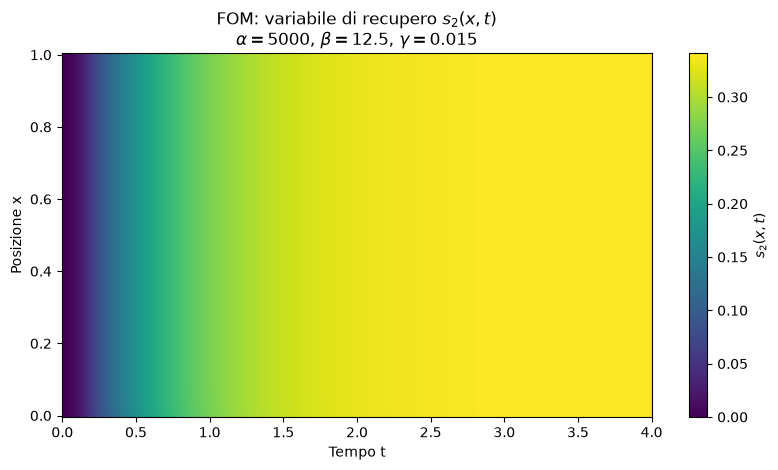

Runtime FOM della figura: 0.243431 s


In [32]:
# Stessa coppia parametrica mostrata nelle slide.
fom_times, fom_s1, fom_s2, fom_runtime = simulate_fhn_fom(
    alpha=5_000.0,
    beta=12.5,
    config=config,
    operators=operators,
)

# Potenziale s1(x,t).
plt.figure(figsize=(8.2, 4.8))
mesh = plt.pcolormesh(
    fom_times,
    operators.x,
    fom_s1,
    shading="auto",
)
plt.colorbar(mesh, label=r"$s_1(x,t)$")
plt.xlabel("Tempo t")
plt.ylabel("Posizione x")
plt.title(
    "FOM: potenziale $s_1(x,t)$\n"
    r"$\alpha=5000$, $\beta=12.5$, $\gamma=0.015$"
)
plt.tight_layout()
plt.savefig(output_dir / "fom_fitzhugh_nagumo_s1.png", dpi=180)
plt.show()

# Variabile di recupero s2(x,t).
plt.figure(figsize=(8.2, 4.8))
mesh = plt.pcolormesh(
    fom_times,
    operators.x,
    fom_s2,
    shading="auto",
)
plt.colorbar(mesh, label=r"$s_2(x,t)$")
plt.xlabel("Tempo t")
plt.ylabel("Posizione x")
plt.title(
    "FOM: variabile di recupero $s_2(x,t)$\n"
    r"$\alpha=5000$, $\beta=12.5$, $\gamma=0.015$"
)
plt.tight_layout()
plt.savefig(output_dir / "fom_fitzhugh_nagumo_s2.png", dpi=180)
plt.show()

print(f"Runtime FOM della figura: {fom_runtime:.6f} s")


## Training FOM e costruzione dei dati lifted

In [33]:
(
    snapshot_times,
    training_s1,
    training_s2,
    training_g,
    training_run_info,
) = generate_training_data(config, operators)

lift_start = time.perf_counter()
lift_data = build_lift_data(
    training_s1,
    training_s2,
    training_g,
    config,
    operators,
)
lift_runtime = time.perf_counter() - lift_start

print("training_s1:", training_s1.shape)
print("training_s2:", training_s2.shape)
print("features:", lift_data.features.shape)
print("reduced_derivative:", lift_data.reduced_derivative.shape)
print(f"Tempo costruzione lift: {lift_runtime:.6f} s")


Training  1/9: alpha=     500, beta=10.0, runtime=  0.235 s
Training  2/9: alpha=     500, beta=12.5, runtime=  0.255 s
Training  3/9: alpha=     500, beta=15.0, runtime=  0.228 s
Training  4/9: alpha=    5000, beta=10.0, runtime=  0.208 s
Training  5/9: alpha=    5000, beta=12.5, runtime=  0.222 s
Training  6/9: alpha=    5000, beta=15.0, runtime=  0.209 s
Training  7/9: alpha=   50000, beta=10.0, runtime=  0.237 s
Training  8/9: alpha=   50000, beta=12.5, runtime=  0.215 s
Training  9/9: alpha=   50000, beta=15.0, runtime=  0.226 s
training_s1: (128, 3609)
training_s2: (128, 3609)
features: (44, 3609)
reduced_derivative: (7, 3609)
Tempo costruzione lift: 0.080723 s


## Correzione numerica delle derivate ridotte per `ranks=(2,2,3)`

In [34]:
# Per rank molto compatti, valutare il RHS sugli stati già proiettati può
# amplificare l'errore di chiusura e rendere instabile il ROM. La correzione
# consiste nel proiettare le derivate FOM valutate sugli snapshot FOM originali.
# Lifting, POD, feature, maschere, regressione e simulatore ROM restano invariati.
training_ds1, training_ds2 = fhn_semidiscrete_rhs(
    training_s1,
    training_s2,
    training_g,
    operators,
    config.gamma,
)
training_dw3 = 2.0 * training_s1 * training_ds1

psi1, psi2, psi3 = lift_data.bases
lift_data.reduced_derivative = np.vstack(
    (
        psi1.T @ training_ds1,
        psi2.T @ training_ds2,
        psi3.T @ training_dw3,
    )
)

assert lift_data.reduced_derivative.shape == lift_data.reduced_state.shape
assert np.all(np.isfinite(lift_data.reduced_derivative))
print("Derivate ridotte corrette:", lift_data.reduced_derivative.shape)


Derivate ridotte corrette: (7, 3609)


## Energia POD e scelta dei modi

,energia_trattenuta_percento,modi_w1,modi_w2,modi_w3,dimensione_totale
0,99.9000,1,1,1,3
1,99.9900,2,2,2,6
2,99.9990,2,2,3,7
3,99.9999,3,2,3,8


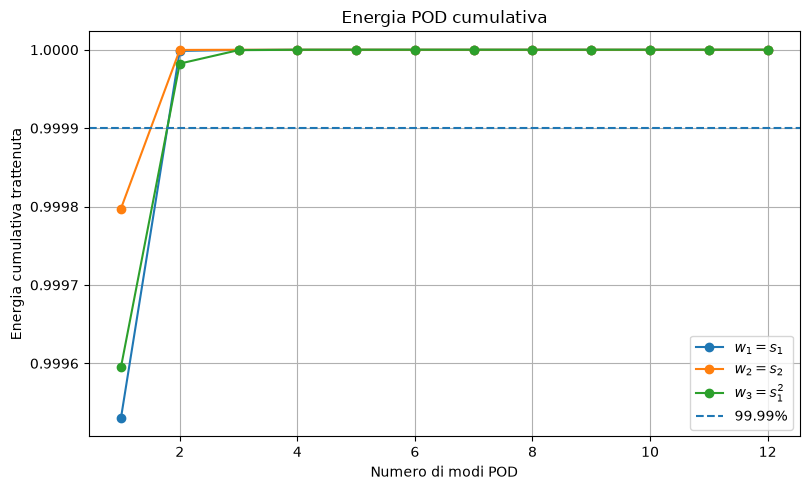

In [35]:
table_energy = energy_table(lift_data.singular_values)
display(table_energy)
table_energy.to_csv(output_dir / "tabella_energia.csv", index=False)

labels = (r"$w_1=s_1$", r"$w_2=s_2$", r"$w_3=s_1^2$")
plt.figure(figsize=(8.2, 5.0))
for singular_values, label in zip(lift_data.singular_values, labels):
    retained = np.cumsum(singular_values**2) / np.sum(singular_values**2)
    n_plot = min(12, retained.size)
    plt.plot(
        np.arange(1, n_plot + 1),
        retained[:n_plot],
        marker="o",
        label=label,
    )
plt.axhline(0.9999, linestyle="--", label="99.99%")
plt.xlabel("Numero di modi POD")
plt.ylabel("Energia cumulativa trattenuta")
plt.title("Energia POD cumulativa")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "energia_pod_cumulativa.png", dpi=180)
plt.show()


## Selezione di $\lambda$: training e validation

lambda=  1.0e-12 | residuo training=2.907e-03 | errore validazione=9.717e-04 | stabile=True
lambda=  1.0e-10 | residuo training=2.937e-03 | errore validazione=9.854e-04 | stabile=True
lambda=  1.0e-08 | residuo training=5.187e-03 | errore validazione=5.761e-03 | stabile=True
lambda=  1.0e-06 | residuo training=6.068e-02 | errore validazione=      inf | stabile=False
lambda=  1.0e-04 | residuo training=2.732e-01 | errore validazione=2.732e-02 | stabile=True
lambda=  1.0e-02 | residuo training=6.695e-01 | errore validazione=      inf | stabile=False


,lambda,residuo_derivate_training,errore_validazione,stabile
0,1.000000e-12,0.002907,0.000972,True
1,1.000000e-10,0.002937,0.000985,True
2,1.000000e-08,0.005187,0.005761,True
3,1.000000e-06,0.060675,inf,False
4,1.000000e-04,0.273231,0.027319,True
5,1.000000e-02,0.669489,inf,False


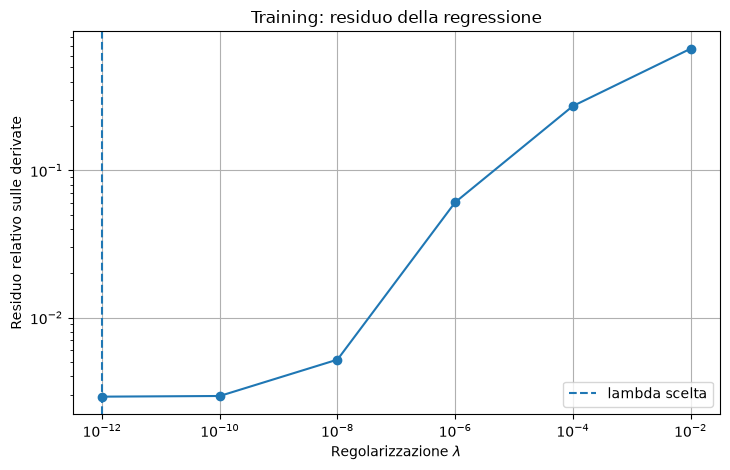

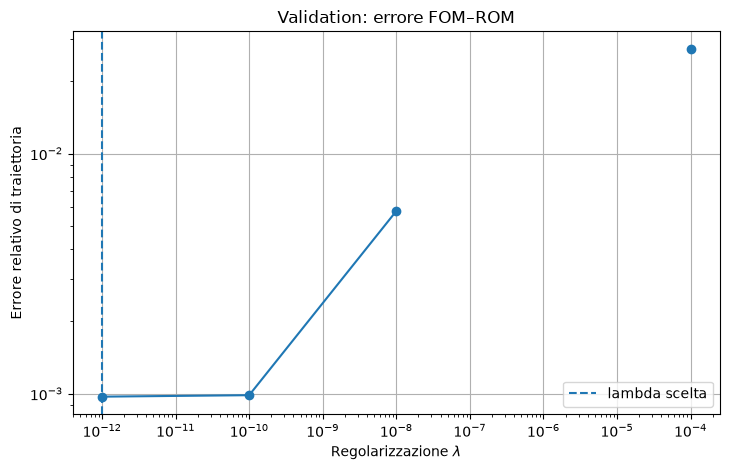

Modello selezionato: ranks=(2, 2, 3), lambda=1.0e-12, residuo training=2.907110e-03, errore validation=9.716592e-04


In [36]:
validation_times, validation_s1, validation_s2, validation_fom_runtime = (
    simulate_fhn_fom(
        config.validation_alpha,
        config.validation_beta,
        config,
        operators,
    )
)

model, regularization_table = choose_regularization(
    lift_data,
    (validation_times, validation_s1, validation_s2),
    config,
)
regularization_table.to_csv(
    output_dir / "selezione_regolarizzazione.csv",
    index=False,
)
display(regularization_table)

finite_validation = regularization_table.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(7.4, 4.8))
plt.loglog(
    finite_validation["lambda"],
    finite_validation["residuo_derivate_training"],
    marker="o",
)
plt.axvline(model.regularization, linestyle="--", label="lambda scelta")
plt.xlabel(r"Regolarizzazione $\lambda$")
plt.ylabel("Residuo relativo sulle derivate")
plt.title("Training: residuo della regressione")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "lambda_residuo_training.png", dpi=180)
plt.show()

plt.figure(figsize=(7.4, 4.8))
plt.loglog(
    finite_validation["lambda"],
    finite_validation["errore_validazione"],
    marker="o",
)
plt.axvline(model.regularization, linestyle="--", label="lambda scelta")
plt.xlabel(r"Regolarizzazione $\lambda$")
plt.ylabel("Errore relativo di traiettoria")
plt.title("Validation: errore FOM–ROM")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "lambda_errore_validazione.png", dpi=180)
plt.show()

print(
    f"Modello selezionato: ranks={model.ranks}, "
    f"lambda={model.regularization:.1e}, "
    f"residuo training={model.training_residual:.6e}, "
    f"errore validation={model.validation_error:.6e}"
)


## Verifica quantitativa degli errori di training e validation

In [37]:
# Errore di traiettoria su tutte le nove simulazioni di training.
training_errors = []
training_pairs = training_parameter_pairs(config)
n_snapshots_per_run = snapshot_times.size

for block_index, (alpha, beta) in enumerate(training_pairs):
    start = block_index * n_snapshots_per_run
    stop = (block_index + 1) * n_snapshots_per_run
    reference_s1 = training_s1[:, start:stop]
    reference_s2 = training_s2[:, start:stop]

    pred_s1, pred_s2, _, _, stable = simulate_lift_rom(
        model.coefficients,
        model.bases,
        model.quadratic_pairs,
        alpha,
        beta,
        snapshot_times,
        config,
    )
    error = (
        trajectory_relative_error(
            pred_s1,
            pred_s2,
            reference_s1,
            reference_s2,
        )
        if stable
        else np.inf
    )
    training_errors.append(
        {
            "alpha": alpha,
            "beta": beta,
            "errore_training": error,
            "stabile": stable,
        }
    )

training_error_table = pd.DataFrame(training_errors)
training_mean_error = float(training_error_table["errore_training"].mean())
training_max_error = float(training_error_table["errore_training"].max())
validation_error = float(model.validation_error)

display(training_error_table)
print(f"Errore medio training: {training_mean_error:.6e}")
print(f"Errore massimo training: {training_max_error:.6e}")
print(f"Errore validation: {validation_error:.6e}")

# Soglie conservative: tutti gli errori devono restare nettamente bassi.
assert np.isfinite(training_error_table["errore_training"]).all()
assert model.training_residual < 1.0e-2
assert training_mean_error < 5.0e-3
assert training_max_error < 2.0e-2
assert validation_error < 1.0e-2
print("Controlli superati: training e validation hanno errore basso.")


,alpha,beta,errore_training,stabile
0,500.0,10.0,0.000571,True
1,500.0,12.5,0.000571,True
2,500.0,15.0,0.000571,True
3,5000.0,10.0,0.000789,True
4,5000.0,12.5,0.000617,True
5,5000.0,15.0,0.000586,True
6,50000.0,10.0,0.008205,True
7,50000.0,12.5,0.002628,True
8,50000.0,15.0,0.001526,True


Errore medio training: 1.784786e-03
Errore massimo training: 8.205023e-03
Errore validation: 9.716592e-04
Controlli superati: training e validation hanno errore basso.


## Test, profili finali ed errore dinamico

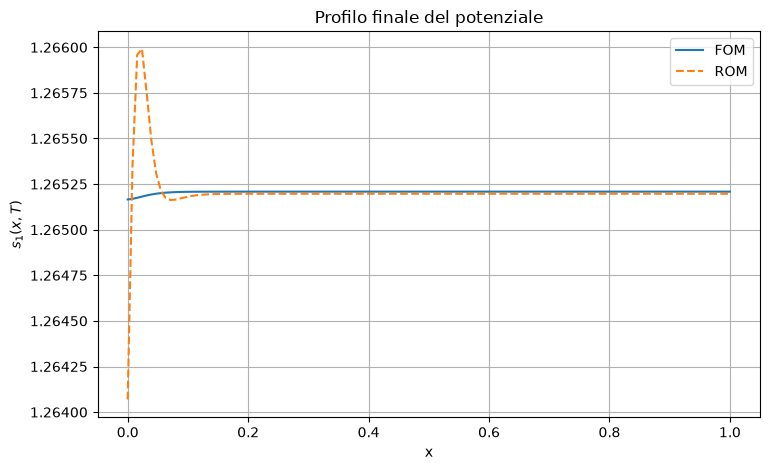

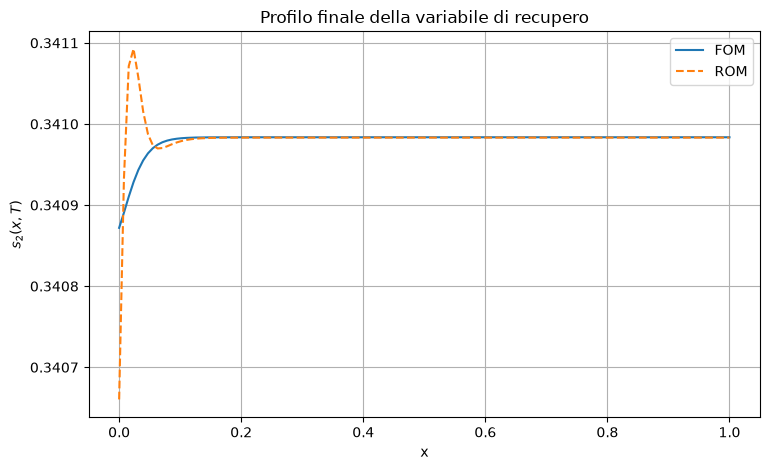

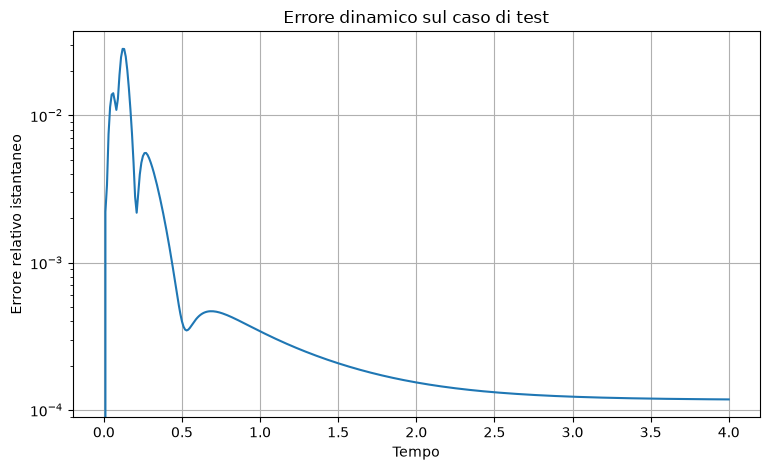

Errore test: 2.324399e-03
Tempo FOM test: 0.249037 s
Tempo ROM test: 0.220899 s


In [38]:
test_times, test_s1, test_s2, test_fom_runtime = simulate_fhn_fom(
    config.test_alpha,
    config.test_beta,
    config,
    operators,
)
(
    test_rom_s1,
    test_rom_s2,
    test_reduced,
    test_rom_runtime,
    test_stable,
) = simulate_lift_rom(
    model.coefficients,
    model.bases,
    model.quadratic_pairs,
    config.test_alpha,
    config.test_beta,
    test_times,
    config,
)
assert test_stable

test_error = trajectory_relative_error(
    test_rom_s1,
    test_rom_s2,
    test_s1,
    test_s2,
)

plt.figure(figsize=(7.8, 4.8))
plt.plot(operators.x, test_s1[:, -1], label="FOM")
plt.plot(operators.x, test_rom_s1[:, -1], linestyle="--", label="ROM")
plt.xlabel("x")
plt.ylabel(r"$s_1(x,T)$")
plt.title("Profilo finale del potenziale")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "profilo_rom_s1.png", dpi=180)
plt.show()

plt.figure(figsize=(7.8, 4.8))
plt.plot(operators.x, test_s2[:, -1], label="FOM")
plt.plot(operators.x, test_rom_s2[:, -1], linestyle="--", label="ROM")
plt.xlabel("x")
plt.ylabel(r"$s_2(x,T)$")
plt.title("Profilo finale della variabile di recupero")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "profilo_rom_s2.png", dpi=180)
plt.show()

instantaneous_error = []
for snapshot_index in range(test_times.size):
    reference = np.concatenate(
        (test_s1[:, snapshot_index], test_s2[:, snapshot_index])
    )
    prediction = np.concatenate(
        (test_rom_s1[:, snapshot_index], test_rom_s2[:, snapshot_index])
    )
    denominator = np.linalg.norm(reference)
    instantaneous_error.append(
        np.linalg.norm(prediction - reference) / denominator
        if denominator > 0.0
        else 0.0
    )

plt.figure(figsize=(7.8, 4.8))
plt.semilogy(test_times, instantaneous_error)
plt.xlabel("Tempo")
plt.ylabel("Errore relativo istantaneo")
plt.title("Errore dinamico sul caso di test")
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / "errore_istantaneo_test.png", dpi=180)
plt.show()

print(f"Errore test: {test_error:.6e}")
print(f"Tempo FOM test: {test_fom_runtime:.6f} s")
print(f"Tempo ROM test: {test_rom_runtime:.6f} s")


## Generalizzazione parametrica

,regime,alpha,beta,errore_relativo,tempo_FOM_s,tempo_ROM_s,stabile
0,training,500.0,10.0,0.000571,0.192232,0.203594,True
1,training,50000.0,15.0,0.001526,0.211795,0.210363,True
2,interpolazione,20000.0,13.5,0.000972,0.198638,0.186159,True
3,extrapolazione,100000.0,17.0,0.002324,0.198920,0.193196,True


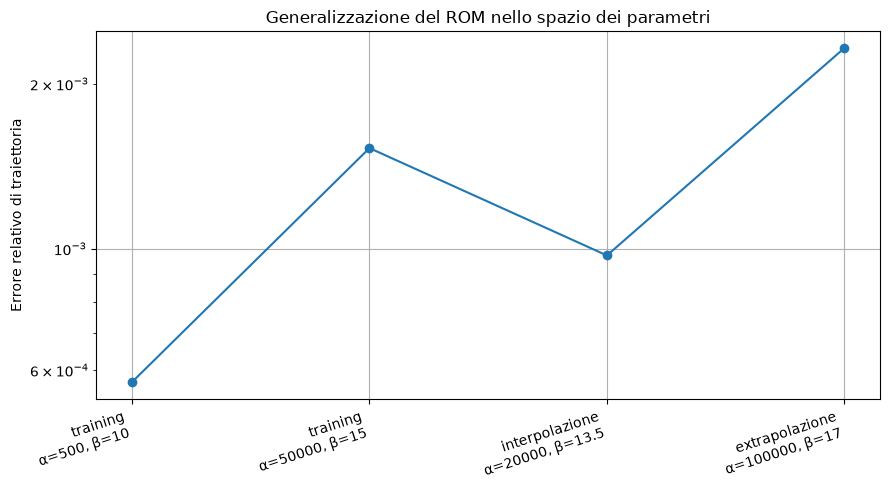

In [39]:
parameter_cases = [
    ("training", 500.0, 10.0),
    ("training", 50_000.0, 15.0),
    ("interpolazione", config.validation_alpha, config.validation_beta),
    ("extrapolazione", config.test_alpha, config.test_beta),
]

parameter_records = []
for regime, alpha, beta in parameter_cases:
    times_case, fom_s1_case, fom_s2_case, fom_time_case = simulate_fhn_fom(
        alpha,
        beta,
        config,
        operators,
    )
    rom_s1_case, rom_s2_case, _, rom_time_case, stable_case = simulate_lift_rom(
        model.coefficients,
        model.bases,
        model.quadratic_pairs,
        alpha,
        beta,
        times_case,
        config,
    )
    error_case = (
        trajectory_relative_error(
            rom_s1_case,
            rom_s2_case,
            fom_s1_case,
            fom_s2_case,
        )
        if stable_case
        else np.inf
    )
    parameter_records.append(
        {
            "regime": regime,
            "alpha": alpha,
            "beta": beta,
            "errore_relativo": error_case,
            "tempo_FOM_s": fom_time_case,
            "tempo_ROM_s": rom_time_case,
            "stabile": stable_case,
        }
    )

parameter_table = pd.DataFrame(parameter_records)
display(parameter_table)
parameter_table.to_csv(
    output_dir / "generalizzazione_parametrica.csv",
    index=False,
)

labels_parameter = [
    f"{row.regime}\nα={row.alpha:g}, β={row.beta:g}"
    for row in parameter_table.itertuples()
]
plt.figure(figsize=(9.0, 5.0))
plt.semilogy(
    np.arange(len(parameter_table)),
    parameter_table["errore_relativo"],
    marker="o",
)
plt.xticks(
    np.arange(len(parameter_table)),
    labels_parameter,
    rotation=18,
    ha="right",
)
plt.ylabel("Errore relativo di traiettoria")
plt.title("Generalizzazione del ROM nello spazio dei parametri")
plt.grid(True)
plt.tight_layout()
plt.savefig(output_dir / "generalizzazione_parametrica.png", dpi=180)
plt.show()


## Confronto dei tempi offline e online

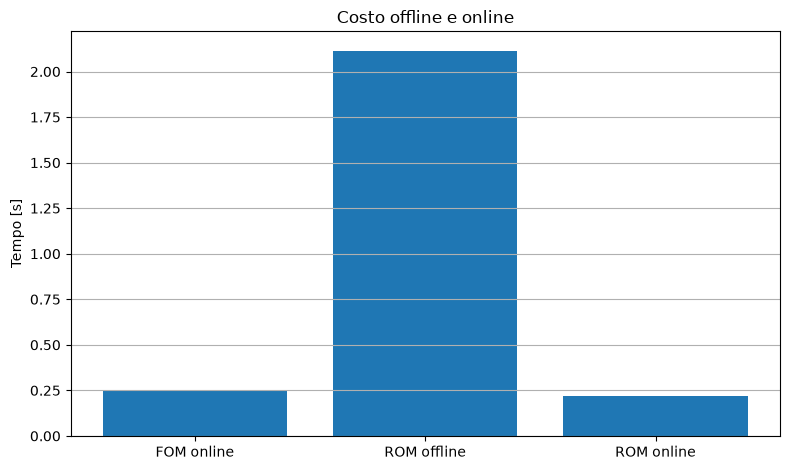

In [40]:
offline_training_time = float(
    sum(record["tempo_FOM_s"] for record in training_run_info)
)
offline_total_time = offline_training_time + lift_runtime

plt.figure(figsize=(8.0, 4.8))
labels_timing = [
    "FOM online",
    "ROM offline",
    "ROM online",
]
values_timing = [
    test_fom_runtime,
    offline_total_time,
    test_rom_runtime,
]
plt.bar(labels_timing, values_timing)
plt.ylabel("Tempo [s]")
plt.title("Costo offline e online")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(output_dir / "tempi_offline_online.png", dpi=180)
plt.show()


## Esperimento finale: matrice piccola e matrice grande

Lo stesso ROM di dimensione $r=7$ viene confrontato con il FOM su una griglia piccola e su una griglia molto grande. I tempi sono mediane di tre esecuzioni.

In [41]:
def median_online_times(
    experiment_config: Config,
    repetitions: int = 3,
) -> tuple[float, float]:
    experiment_operators = build_boundary_neumann(
        experiment_config.n_space,
        experiment_config.length,
    )
    fom_times_measured = []
    rom_times_measured = []

    for _ in range(repetitions):
        experiment_times, _, _, fom_time = simulate_fhn_fom(
            experiment_config.validation_alpha,
            experiment_config.validation_beta,
            experiment_config,
            experiment_operators,
        )
        _, _, _, rom_time, stable = simulate_lift_rom(
            model.coefficients,
            model.bases,
            model.quadratic_pairs,
            experiment_config.validation_alpha,
            experiment_config.validation_beta,
            experiment_times,
            experiment_config,
        )
        assert stable
        fom_times_measured.append(fom_time)
        rom_times_measured.append(rom_time)

    return (
        float(np.median(fom_times_measured)),
        float(np.median(rom_times_measured)),
    )

# Matrice piccola: il costo fisso dell'integratore ROM domina.
small_config = replace(
    config,
    n_space=40,
    final_time=0.4,
    dt=2.0e-3,
    snapshot_dt=2.0e-2,
)

# Matrice grande: il FOM deve risolvere un sistema con 16384 incognite.
large_config = replace(
    config,
    n_space=16_384,
    final_time=0.4,
    dt=2.0e-3,
    snapshot_dt=2.0e-2,
)

small_fom_time, small_rom_time = median_online_times(small_config)
large_fom_time, large_rom_time = median_online_times(large_config)

matrix_timing_table = pd.DataFrame(
    [
        {
            "caso": "matrice piccola",
            "n_space": small_config.n_space,
            "tempo_FOM_s": small_fom_time,
            "tempo_ROM_s": small_rom_time,
            "vincitore": "FOM" if small_fom_time < small_rom_time else "ROM",
            "speedup_FOM_su_ROM": small_fom_time / small_rom_time,
        },
        {
            "caso": "matrice grande",
            "n_space": large_config.n_space,
            "tempo_FOM_s": large_fom_time,
            "tempo_ROM_s": large_rom_time,
            "vincitore": "FOM" if large_fom_time < large_rom_time else "ROM",
            "speedup_FOM_su_ROM": large_fom_time / large_rom_time,
        },
    ]
)
display(matrix_timing_table)
matrix_timing_table.to_csv(
    output_dir / "confronto_matrice_piccola_grande.csv",
    index=False,
)

assert small_fom_time < small_rom_time
assert large_rom_time < large_fom_time
print("Controllo tempi superato: FOM vince sul piccolo, ROM vince sul grande.")


,caso,n_space,tempo_FOM_s,tempo_ROM_s,vincitore,speedup_FOM_su_ROM
0,matrice piccola,40,0.007995,0.065010,FOM,0.122985
1,matrice grande,16384,0.160788,0.065293,ROM,2.462544


Controllo tempi superato: FOM vince sul piccolo, ROM vince sul grande.


## Riepilogo finale

In [42]:
final_summary = pd.DataFrame(
    [
        {
            "ranks": str(config.ranks),
            "dimensione_ROM": sum(config.ranks),
            "lambda": model.regularization,
            "residuo_derivate_training": model.training_residual,
            "errore_medio_training": training_mean_error,
            "errore_massimo_training": training_max_error,
            "errore_validation": validation_error,
            "errore_test": test_error,
            "matrice_piccola_vincitore": matrix_timing_table.iloc[0]["vincitore"],
            "matrice_grande_vincitore": matrix_timing_table.iloc[1]["vincitore"],
        }
    ]
)
display(final_summary)
final_summary.to_csv(output_dir / "riepilogo_finale.csv", index=False)
save_model(model, config, output_dir)

assert tuple(config.ranks) == (2, 2, 3)
assert final_summary.iloc[0]["matrice_piccola_vincitore"] == "FOM"
assert final_summary.iloc[0]["matrice_grande_vincitore"] == "ROM"
print(f"Risultati salvati in: {output_dir.resolve()}")


,ranks,dimensione_ROM,lambda,residuo_derivate_training,errore_medio_training,errore_massimo_training,errore_validation,errore_test,matrice_piccola_vincitore,matrice_grande_vincitore
0,"(2, 2, 3)",7,1.000000e-12,0.002907,0.001785,0.008205,0.000972,0.002324,FOM,ROM


Risultati salvati in: C:\Users\frmar\OneDrive\Desktop\FRANCESCO\UNIVERSITA\MAGISTRALE\1 ANNO\1A2S\Data Mining\Lift_and_Learn\risultati_fhn_notebook_ranks_223
